In [ ]:
from tensorflow.keras.models import load_model
model = load_model(r"models\violence_detection_model.h5")

print("Model loaded successfully")

Model loaded successfully


In [2]:
import os
import cv2
import numpy as np
from collections import defaultdict
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
processed_path = r"processed_data"

violence_path = os.path.join(processed_path, "V")
nonviolence_path = os.path.join(processed_path, "NV")

In [4]:
video_frames = defaultdict(list)

# Violence frames
for frame in os.listdir(violence_path):
    video_id = "_".join(frame.split("_")[1:3])
    video_frames[video_id].append(os.path.join(violence_path, frame))

# Non-violence frames
for frame in os.listdir(nonviolence_path):
    video_id = "_".join(frame.split("_")[1:3])
    video_frames[video_id].append(os.path.join(nonviolence_path, frame))

video_ids = list(video_frames.keys())

print("Total videos:", len(video_ids))

Total videos: 2000


In [5]:
labels = []

for vid in video_ids:
    if vid.startswith("V"):
        labels.append(1)
    else:
        labels.append(0)

In [6]:
train_ids, test_ids, train_labels, test_labels = train_test_split(
    video_ids,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Test videos:", len(test_ids))

Test videos: 400


In [28]:
import tensorflow as tf
import numpy as np
import cv2

class VideoGenerator(tf.keras.utils.Sequence):

    def __init__(self, video_ids, labels, video_frames, batch_size=4):
        self.video_ids = video_ids
        self.labels = labels
        self.video_frames = video_frames
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.video_ids) / self.batch_size))

    def __getitem__(self, idx):

        batch_ids = self.video_ids[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_labels = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]

        X = []
        y = []

        for vid, label in zip(batch_ids, batch_labels):

            frames = sorted(self.video_frames[vid])

            # Uniformly sample 16 frames across the video
            if len(frames) >= 16:
                indices = np.linspace(0, len(frames) - 1, 16).astype(int)
                frames = [frames[i] for i in indices]
            else:
                # If video has fewer frames, repeat the last frame
                frames = frames + [frames[-1]] * (16 - len(frames))

            sequence = []

            for frame in frames:
                img = cv2.imread(frame)
                img = cv2.resize(img, (160,160))
                img = img / 255.0
                sequence.append(img)

            X.append(sequence)
            y.append(label)

        return np.array(X), np.array(y)

In [29]:
test_gen = VideoGenerator(test_ids, test_labels, video_frames, batch_size=4)

In [30]:
predictions = model.predict(test_gen)

y_pred = (predictions > 0.5).astype(int).flatten()
y_true = np.array(test_labels[:len(y_pred)])

100/100 [==============================] - 10s 104ms/step


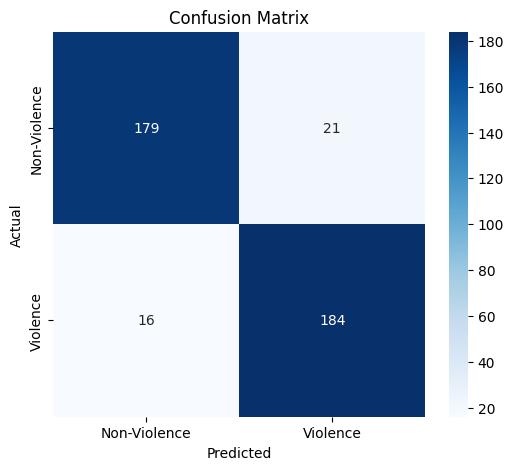

In [31]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Violence","Violence"],
    yticklabels=["Non-Violence","Violence"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       200
           1       0.90      0.92      0.91       200

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400



In [33]:
from collections import Counter

print("Label distribution in dataset:")
print(Counter(labels))

print("Train distribution:")
print(Counter(train_labels))

print("Test distribution:")
print(Counter(test_labels))

Label distribution in dataset:
Counter({1: 1000, 0: 1000})
Train distribution:
Counter({1: 800, 0: 800})
Test distribution:
Counter({0: 200, 1: 200})


In [34]:
from collections import Counter

print("Prediction distribution:")
print(Counter(y_pred))

Prediction distribution:
Counter({1: 205, 0: 195})


In [35]:
print("Model input shape:", model.input_shape)

Model input shape: (None, 16, 160, 160, 3)


In [36]:
X, y = test_gen[0]
print(X.shape)

(4, 16, 160, 160, 3)


In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9075


In [38]:
train_gen = VideoGenerator(train_ids, train_labels, video_frames, batch_size=4)

train_predictions = model.predict(train_gen)

train_pred = (train_predictions > 0.5).astype(int).flatten()
train_true = np.array(train_labels[:len(train_pred)])

from sklearn.metrics import accuracy_score
print("Train Accuracy:", accuracy_score(train_true, train_pred))

400/400 [==============================] - 70s 175ms/step
Train Accuracy: 0.999375


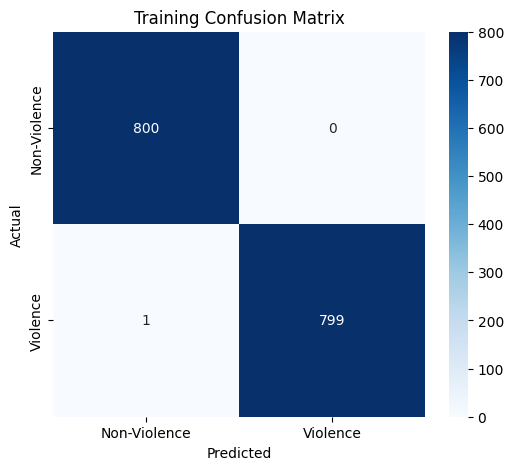

In [39]:
cm_train = confusion_matrix(train_true, train_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues",
xticklabels=["Non-Violence","Violence"],
yticklabels=["Non-Violence","Violence"])

plt.title("Training Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

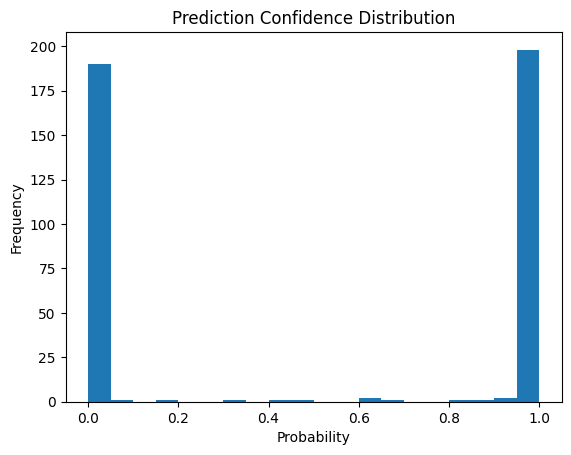

In [40]:
plt.hist(predictions, bins=20)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

In [41]:
wrong = np.where(y_true != y_pred)[0]

print("Total wrong predictions:", len(wrong))

for i in wrong[:10]:
    print("Actual:", y_true[i], "Predicted:", y_pred[i])

Total wrong predictions: 37
Actual: 0 Predicted: 1
Actual: 0 Predicted: 1
Actual: 0 Predicted: 1
Actual: 0 Predicted: 1
Actual: 0 Predicted: 1
Actual: 0 Predicted: 1
Actual: 1 Predicted: 0
Actual: 1 Predicted: 0
Actual: 0 Predicted: 1
Actual: 0 Predicted: 1


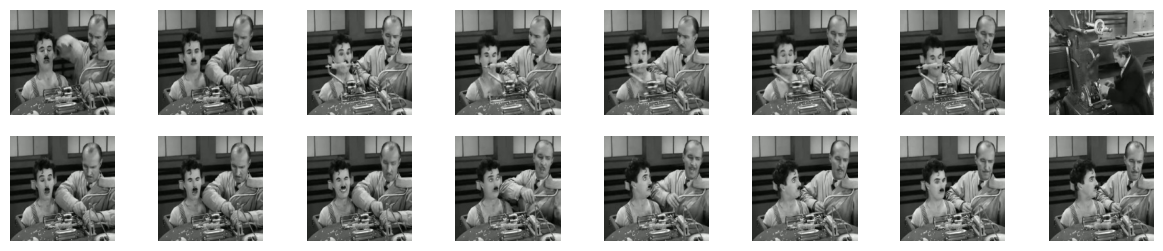

In [43]:
import matplotlib.pyplot as plt
import random

vid = random.choice(test_ids)

frames = sorted(video_frames[vid])
indices = np.linspace(0, len(frames)-1, 16).astype(int)
frames = [frames[i] for i in indices]

plt.figure(figsize=(15,3))

for i,f in enumerate(frames):
    img = cv2.imread(f)
    img = cv2.resize(img,(160,160))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,8,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()